# W05B · B · 노이즈 예측을 학습하고 역확산으로 생성하기
2026-09-30 · 생성형 인공지능 · 주교재 3장, 4.1–4.2

MNIST와 작은 시간조건 U-Net으로 데이터·노이즈·학습·샘플링·평가를 연결합니다. 체크포인트는 실제 수업 코드로 미리 학습했습니다. 마지막 누적 앱에는 CLIP 검색도 준비됩니다. 지난 노트북을 실행하지 않아도 새 사본에서 시작할 수 있습니다.
**CPU 기본 / Python 3.12·3.13 / 패키지 0.1.8 / 고정 태그 2026-fall-w05b**. 유료 API 키와 개인 파일 업로드가 필요하지 않습니다.
Drive에 사본을 저장한 뒤 첫 셀부터 실행하세요. 빈칸은 독립된 연습 변수이므로 None을 남겨도 기본 관찰은 진행됩니다.
출력이 예상과 다르면 오류를 숨기지 말고 마지막으로 성공한 셀부터 확인하세요.

[강의 A](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/course/notion/w05b/w05b-clip-search.md) · [강의 B](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/course/notion/w05b/w05b-diffusion.md) · [기록지](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/course/notion/w05b/w05b-workbook.md) · [API 정의와 사용법](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/W05B-API.md)


## 0. 독립 실행 환경
설치 셀은 필요한 버전을 확인합니다. 이미 import한 패키지를 교체해야 하는 경우 런타임을 재시작하고 첫 셀부터 실행하세요.
설치·모델 준비·실제 계산의 시간을 구분합니다. 모델 준비 실패를 가짜 결과로 바꾸지 않습니다.


In [ ]:
import sys,subprocess,os,time
from pathlib import Path
from importlib.metadata import version,PackageNotFoundError
PUBLIC_REF='2026-fall-w05b'
try:
    ready=all(version(p)==v for p,v in [('luna-genai','0.1.8'),('transformers','5.15.1'),('gradio','6.26.0'),('diffusers','0.40.0')])
except PackageNotFoundError:
    ready=False
if not ready:
    if any(p in sys.modules for p in ('luna_genai','torch','transformers','gradio','diffusers')):
        raise RuntimeError('런타임을 재시작한 뒤 첫 설치 셀부터 실행하세요.')
    package=str(Path('src').resolve()) if Path('src/pyproject.toml').exists() else f'git+https://github.com/lunalab-ai/genAI.git@{PUBLIC_REF}#subdirectory=src'
    subprocess.run([sys.executable,'-m','pip','install','-q',package],check=True)
print('Python',sys.version.split()[0],'; package',version('luna-genai'),'; diffusers',version('diffusers'))
IN_COLAB='COLAB_RELEASE_TAG' in os.environ
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
torch.set_num_threads(2)
started=time.perf_counter()


## 1. 입력 데이터와 실제 학습 기록
[`load_mnist`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/autoencoder.py#L92)는 공식 MNIST를 처음 한 번 약 11.6 MB 다운로드하고 체크섬을 확인합니다. 아래 split은 train 12000, validation 1000, test 1000, seed1337입니다. train/validation은 공식 학습 집합의 서로 다른 인덱스입니다.
반환 이미지 `(N,1,28,28)`는 [0,1]입니다. 확산 모델에는 `2*x-1`로 [-1,1]을 사용합니다. 숫자 라벨은 학습에 넣지 않습니다.
[`load_diffusion_checkpoints`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion.py#L204)는 패키지의 NPZ와 SHA-256을 확인하여 initial·early·trained 모델, 기록 사전을 반환합니다. 다운로드나 학습을 하지 않습니다.
[`TinyTimeUNet`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion.py#L85)는 새 미학습 모델을 초기화하며 seed20260930이 기본입니다. 학습된 객체와 새 객체를 구별하세요.


In [ ]:
from luna_genai.autoencoder import load_mnist
from luna_genai.diffusion import (TinyTimeUNet,make_scheduler,forward_noise,training_step,
    evaluate_noise,sample_diffusion,load_diffusion_checkpoints,image_grid)
from luna_genai.diffusion_app import build_study_app,noise_view,generation_view,APP_CSS
data=load_mnist(train_size=12000,validation_size=1000,test_size=1000,seed=1337)
train=data.train*2-1;validation=data.validation*2-1;test=data.test*2-1
models,record=load_diffusion_checkpoints()
print('새 MNIST 다운로드:',data.downloads or '없음: 캐시 재사용')
print('shape:',train.shape,validation.shape,test.shape,'범위:',float(train.min()),float(train.max()))
print('train/validation 중복:',len(np.intersect1d(data.train_ids,data.validation_ids)))
display(pd.DataFrame([dict(name=k,step=v['step'],ema=v['ema'],sha256=v['sha256']) for k,v in record['checkpoints'].items()]))
print('체크포인트 실제 학습:',record['steps'],'step, batch',record['batch_size'],'; 모수',record['parameters'])
fig=image_grid(test[:8],title='Held-out MNIST: [-1,1]');display(fig);plt.close(fig)


### B1 · 학습 입력·정답·라벨 구별
이 실습에서 숫자 라벨 7이 loss의 정답인가요? 체크포인트 불러오기는 학습인가요? 힌트: 이미지, ε, 숫자 이름을 구별합니다.


## 2. 한 식으로 원하는 시점의 노이즈 만들기
[`make_scheduler`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion.py#L24)는 100단계의 고정 DDPM 스케줄을 만듭니다. 학습된 모수는 없습니다. [`forward_noise`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion.py#L49)는 깨끗한 이미지, int64 시점 벡터, 같은 크기 Gaussian 잡음에서 noisy 이미지를 반환합니다.

$$x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon,\qquad \epsilon\sim\mathcal N(0,I).$$

코드의 t=0은 첫 번째 노이즈 단계이고 이미 약간의 잡음이 있습니다. 깨끗한 원본은 따로 표시합니다. 이 노트북의 코드 t=99가 수학적 100번째 단계에 해당합니다.
같은 ε로 여러 시점을 비교하는 그림은 **주변분포 비교**입니다. 단계마다 새 ε를 뽑아 연결한 하나의 전방 Markov 경로와 같다고 말하지 않습니다.
[DDPMScheduler.add_noise 공식 API](https://huggingface.co/docs/diffusers/api/schedulers/ddpm#diffusers.DDPMScheduler.add_noise)와 직접 계산을 대조합니다.


In [ ]:
scheduler=make_scheduler()
clean=test[:1]
epsilon=torch.randn(clean.shape,generator=torch.Generator().manual_seed(42))
levels=[0,24,49,74,99]
fig,axes=plt.subplots(1,6,figsize=(12,3))
axes[0].imshow(clean[0,0],cmap='gray',vmin=-1,vmax=1);axes[0].set_title('Clean x0')
for ax,t in zip(axes[1:],levels):
    noisy=forward_noise(clean,torch.tensor([t]),epsilon)
    alpha=scheduler.alphas_cumprod[t]
    manual=alpha.sqrt()*clean+(1-alpha).sqrt()*epsilon
    assert torch.allclose(noisy,manual)
    ax.imshow(noisy[0,0],cmap='gray',vmin=-1,vmax=1);ax.set_title(f'code t={t}')
for ax in axes:ax.axis('off')
plt.show()
display(pd.DataFrame([dict(t=t,alpha_bar=float(scheduler.alphas_cumprod[t]),signal=float(scheduler.alphas_cumprod[t].sqrt()),noise=float((1-scheduler.alphas_cumprod[t]).sqrt())) for t in levels]))
print('ε의 표본 평균/표준편차:',float(epsilon.mean()),float(epsilon.std()))


### B2 · 직접 계산과 잘못된 잡음 찾기
ᾱ=0.64, x0=0.5, ε=-1인 한 픽셀의 xt를 계산하세요. torch.rand_like로 잡음을 만들면 무엇이 달라지나요? 힌트: 제곱근과 분포.


In [ ]:
my_pixel_xt=None  # 수계산 결과
# 서로 다른 시점 비교와 별개인 실제 전방 Markov 경로
path=clean.clone();g=torch.Generator().manual_seed(7);forward_frames=[]
for t in range(100):
    beta=scheduler.betas[t]
    path=(1-beta).sqrt()*path+beta.sqrt()*torch.randn(path.shape,generator=g)
    if t in levels:forward_frames.append(path.clone())
fig=image_grid(torch.cat(forward_frames),columns=5,title='One forward Markov path: fresh noise per step')
display(fig);plt.close(fig)


## 3. 시간조건 U-Net: 무엇을 입력하고 무엇을 예측하나
[`TinyTimeUNet.forward`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion.py#L104)는 `(B,1,28,28)` noisy 이미지와 `(B,)` 시점을 받아 같은 크기의 **노이즈**를 예측합니다. 정답 ε를 forward에 넣지 않습니다.
28→14→7에서 넓은 문맥을 모으고, 7→14→28로 해상도를 회복합니다. skip은 같은 해상도의 특징을 채널 방향으로 이어 붙입니다. 시간 표현은 모든 블록에 더합니다.
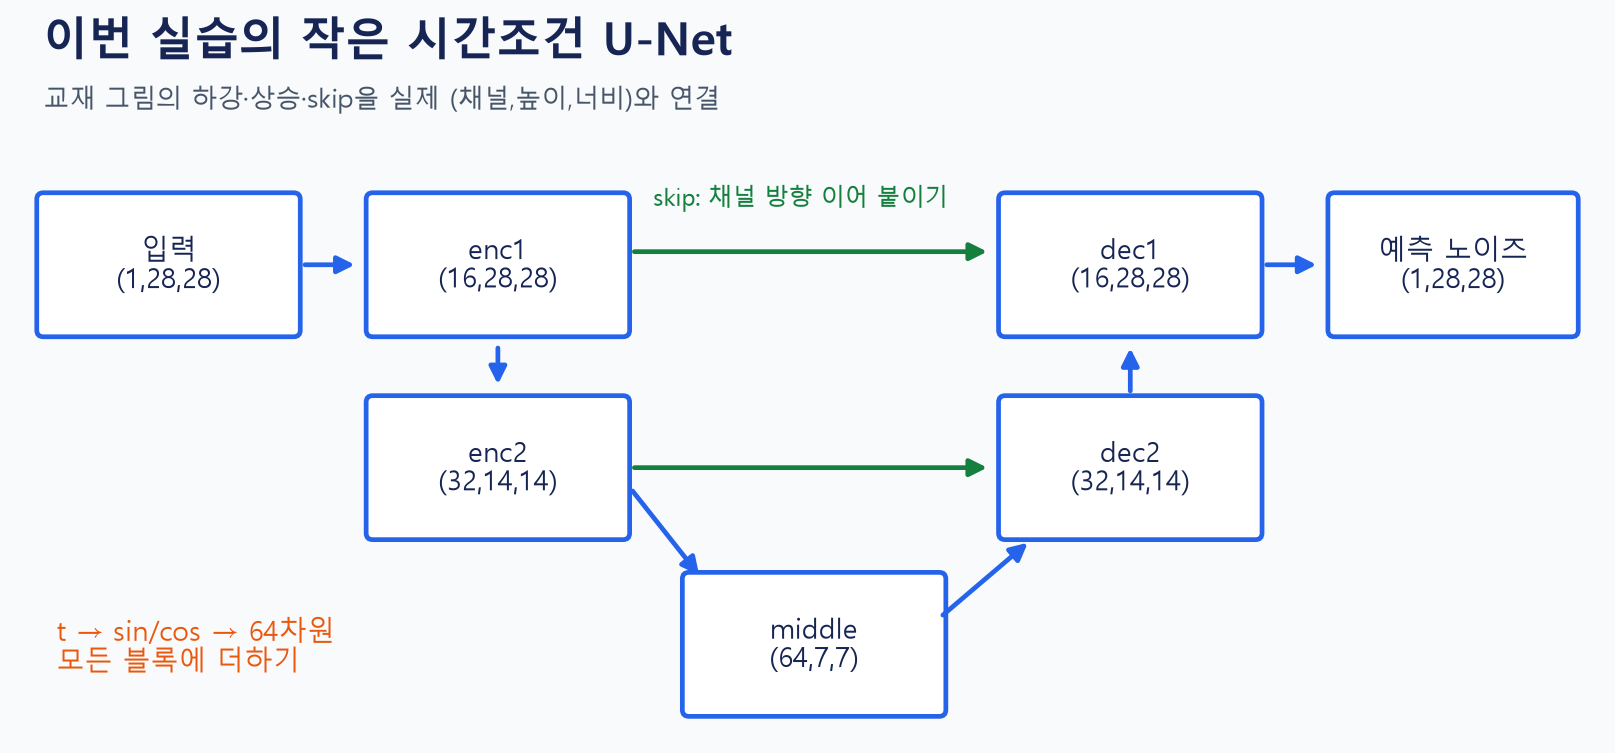
수업용 자체 도식. 교재의 64×64 RGB 나비 모델보다 작지만 시간조건·skip·노이즈 회귀의 역할은 유지합니다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/2026-fall-w05b/course/notion/w05b/assets/12-unet-shapes.png)


In [ ]:
fresh=TinyTimeUNet()
batch=train[:16]
g=torch.Generator().manual_seed(23)
batch_t=torch.randint(100,(len(batch),),generator=g)
batch_noise=torch.randn(batch.shape,generator=g)
batch_noisy=forward_noise(batch,batch_t,batch_noise)
prediction=fresh(batch_noisy,batch_t)
print('x_t:',batch_noisy.shape,'t:',batch_t.shape,'예측 ε:',prediction.shape,'정답 ε:',batch_noise.shape)
print('MSE:',float(torch.nn.functional.mse_loss(prediction,batch_noise).detach()))


### B3 · 출력의 의미와 디버깅
출력 shape이 이미지와 같으니 원본 픽셀과 MSE를 계산해도 같은 학습인가요? t를 주지 않아도 같은 결과인가요?


## 4. 실제 학습 한 단계: gradient와 모수 갱신을 분리하기
[`training_step`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion.py#L122)는 clean·t·ε에서 noisy 입력을 만들고 MSE→backward→optimizer.step을 수행합니다. **모델과 optimizer 상태를 실제로 바꿉니다.**
반환값 loss, gradient_norm, backward_parameter_change, parameter_change를 읽습니다. backward 뒤에는 gradient가 생기지만 모수 값은 같아야 합니다.
[MSELoss](https://docs.pytorch.org/docs/2.8/generated/torch.nn.MSELoss.html)의 mean은 배치·채널·높이·너비 전체 원소 평균입니다.

$$L_{\mathrm{simple}}=\frac{1}{BCHW}\sum_{b,c,h,w}(\epsilon_{bchw}-\epsilon_\theta(x_t,t)_{bchw})^2.$$

아래 짧은 8회 학습은 갱신을 관찰하기 위한 실험입니다. 좋은 숫자 생성을 보장하는 학습량이 아닙니다. 미리 학습한 체크포인트와 구별합니다.


In [ ]:
optimizer=torch.optim.Adam(fresh.parameters(),lr=.001)
first_step=training_step(fresh,optimizer,batch,batch_t,batch_noise)
display(pd.DataFrame([first_step]))
short_history=[first_step['loss']]
for step in range(7):
    ids=torch.randint(len(train),(16,),generator=g)
    t=torch.randint(100,(16,),generator=g)
    eps=torch.randn((16,1,28,28),generator=g)
    short_history.append(training_step(fresh,optimizer,train[ids],t,eps)['loss'])
print('짧은 실제 학습의 배치 loss:',short_history)


### B4 · 학습 추적과 손실 빈칸
loss=(prediction-target).square().sum()을 평균 손실로 고치세요. backward_parameter_change가 0인데 gradient_norm이 양수인 것은 실패인가요? 힌트: 계산과 갱신은 다른 단계입니다.


In [ ]:
my_mean_loss=None  # prediction과 batch_noise로 평균 제곱 오차 계산


## 5. 고정 평가로 학습 전후 비교하기
[`evaluate_noise`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion.py#L148)는 고정 이미지·seed901 잡음과 시점 0/24/49/74/99에서 noise-MSE를 계산합니다. 반환 표는 t, mse, zero_mse, images입니다. 평가 시 모델 모드를 임시로 바꾸고 복원하며 학습하지 않습니다.
zero_mse는 항상 0만 예측하는 기준선입니다. ε가 표준정규이면 평균적으로 약1입니다. 같은 이미지를 평가하더라도 매번 t·ε가 달라지면 공정한 작은 비교가 어려워집니다.
원래 학습 기록의 validation 곡선과, 지금 새로 계산하는 test 결과를 구별합니다.


In [ ]:
evaluation={name:evaluate_noise(model,test[:64]) for name,model in models.items()}
display(pd.concat([frame.assign(model=name) for name,frame in evaluation.items()],ignore_index=True))
fig,axes=plt.subplots(1,2,figsize=(11,4))
curve=pd.DataFrame(record['curve'])
axes[0].plot(curve.step,curve.validation_mse,label='fixed validation');axes[0].set(xlabel='training step',ylabel='epsilon MSE');axes[0].legend()
for name,frame in evaluation.items():axes[1].plot(frame.t,frame.mse,'o-',label=name)
axes[1].axhline(evaluation['trained'].zero_mse.mean(),ls='--',color='black',label='zero predictor')
axes[1].set(xlabel='code t',ylabel='epsilon MSE');axes[1].legend();plt.show()


### B5 · 낮은 손실과 좋은 생성 구별
trained의 MSE가 낮으면 모든 생성 이미지가 좋은 숫자라고 결론 내릴 수 있나요? 비교에서 고정해야 할 것은 무엇인가요?


## 6. 노이즈에서 출발하여 실제로 100회 갱신하기
[`sample_diffusion`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion.py#L173)는 source image 없이 Gaussian에서 시작합니다. 기본 count8, seed42로 100회 scheduler.step을 실행하고 images·initial·frames·steps를 반환합니다. 모델을 학습하지 않습니다.
각 frame의 input은 현재 상태, predicted_clean은 원본 추정, previous는 다음 상태입니다. 원본 추정값을 그대로 다음 상태로 쓰는 것이 아닙니다.
[`image_grid`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion.py#L225)는 공통 [-1,1] 표시 범위로 그림을 만듭니다. 표시용 clipping은 학습이나 샘플링의 상태를 바꾸지 않습니다.
[DDPMScheduler.step](https://huggingface.co/docs/diffusers/api/schedulers/ddpm#diffusers.DDPMScheduler.step)은 스케줄 계수와 분산을 사용합니다. `x_t - predicted_noise`와 같지 않습니다.


In [ ]:
initial_samples=sample_diffusion(models['initial'],count=8,seed=42)
trained_samples=sample_diffusion(models['trained'],count=8,seed=42)
for name,result in [('initial',initial_samples),('trained',trained_samples)]:
    fig=image_grid(result['images'],title=f'{name}: first 8 samples, seed 42')
    display(fig);plt.close(fig)
frame=trained_samples['frames'][1]
print('관찰 시점:',frame['t'],'원본 추정과 다음 상태 차이:',float((frame['predicted_clean']-frame['previous']).abs().mean()))
fig,axes=plt.subplots(2,5,figsize=(11,4))
for j,item in enumerate(trained_samples['frames']):
    for row,key in enumerate(['input','predicted_clean']):
        axes[row,j].imshow(item[key][0,0],cmap='gray',vmin=-1,vmax=1)
        axes[row,j].set_title(f'{key} t={item["t"]}');axes[row,j].axis('off')
plt.tight_layout();plt.show()


### B6 · 샘플링 반복의 빈칸
현재 x와 t에서 epsilon을 예측한 후 scheduler.step을 호출하여 다음 x를 얻는 두 줄을 적으세요. 힌트: prev_sample 필드. 왜 깨끗한 원본이 필요 없나요?


## 7. 누적 웹 앱: 검색·노이즈·학습 전후
[`noise_view`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion_app.py#L13)는 이미지 번호·t·seed에서 원본, noisy 표시 이미지, 실제 계수·범위를 반환합니다.
[`generation_view`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion_app.py#L35)는 체크포인트 이름·seed로 실제 100회 역확산을 수행하여 생성 격자·경로 그림·설명을 반환합니다.
[`build_study_app`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w05b/src/luna_genai/diffusion_app.py#L57)에 준비된 CLIP, 체크포인트, test 이미지를 전달하면 세 탭이 연결됩니다. A를 실행하지 않았어도 아래 셀에서 CLIP을 독립적으로 준비합니다. 최초 가중치 약605 MB가 필요하고 캐시는 재사용합니다.


### B7 · 노이즈 관찰 버튼 조립
Slider(index), Slider(t), Number(seed)를 noise_view에 연결하는 작은 앱을 작성하세요. 출력은 Image 두 개와 JSON입니다. 힌트: images는 고정된 context입니다.


In [ ]:
from luna_genai.semantic_search import CLIPSearch
from luna_genai.clip_teaching import compare_search
search_lab=CLIPSearch();search_lab.index_images()
app=build_study_app(search_lab=search_lab,models=models,images=test)
preview=noise_view(0,49,42,test)
assert preview[0].shape==preview[1].shape==(28,28)
search_preview=compare_search('a cat in the snow','a cat indoors',3,search_lab)
print('누적 앱 준비:',len(app.config['dependencies']),'개 버튼; 실제 CLIP',search_lab.image_embeddings.shape)


In [ ]:
assert not np.intersect1d(data.train_ids,data.validation_ids).size
assert first_step['gradient_norm']>0 and first_step['parameter_change']>0
assert first_step['backward_parameter_change']==0
assert evaluation['trained'].mse.mean()<evaluation['initial'].mse.mean()
assert trained_samples['steps']==100 and trained_samples['images'].shape==(8,1,28,28)
assert torch.isfinite(trained_samples['images']).all()
assert len(search_preview[0])==len(search_preview[1])==3
assert len(app.config['dependencies'])==3
print('W05B B 검증 통과: 실제 학습, 고정 평가, 체크포인트, 100단계 샘플링, 누적 앱 callback')
print('환경 설치 이후 경과:',round(time.perf_counter()-started,1),'초')


### 마지막: 새 탭의 웹 앱에서 설명하기
1. 검색 탭: 같은 대상에서 속성 한 단어를 바꾸고 ID·사진·점수를 비교합니다.
2. 노이즈 탭: 이미지와 seed를 고정하고 t만 바꿉니다. 실제 값이 [-1,1] 밖에 나갈 수 있음을 JSON에서 확인합니다.
3. 생성 탭: seed를 고정하고 initial→trained로 바꿉니다. 생성된 8장 모두를 보고 흐린 획·애매한 숫자·반복 형태도 기록합니다.

마지막 셀의 공유 URL을 새 탭에서 여세요. 공유 URL은 런타임 종료 후 만료됩니다. 기본 실습은 CPU이며, GPU를 선택할 필요가 없습니다.
교재의 나비 64×64 RGB 전체 학습은 별도 장시간 GPU 실험입니다. 이번 모델의 성능을 그 모델의 재현 성능으로 읽지 않습니다.


In [ ]:
if IN_COLAB:
    app.launch(share=True,inline=False,allowed_paths=search_lab.gallery.path.tolist(),css=APP_CSS,show_error=True)
    print('누적 앱 새 탭:',app.share_url)
else:
    print('로컬 실행: app.launch(inbrowser=True, allowed_paths=search_lab.gallery.path.tolist(), css=APP_CSS)')
